In [4]:
import seaborn as sns

df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


# now we are checking that if there any null values are there or not?

In [5]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

## now we have 2 options to clean the data 
### delete by the rows 
### delete by the columns

In [8]:
df.shape

# this shows that there are 891 rows and 15 columns 

(891, 15)

In [10]:
df.dropna().shape  # -> this shows if you delete the data by rows then you will loose a lot of data by rows

(182, 15)

In [12]:
# now by column wise lets say -- deck columns have very high null or missing values so if we delete that column
# 1. axis ka seedha matlab:
# axis=0 (Rows / Default): Operation upar se neeche (rows ke across) chalta hai.
# axis=1 (Columns): Operation left se right (columns ke across) chalta hai.
# text
#                axis=1 (Columns) ───►
#           ┌───────┬───────┬───────┐
#           │ col1  │ col2  │ deck  │
#           ├───────┼───────┼───────┤
#  axis=0   │   1   │   A   │   C   │
#  (Rows)   │   2   │   B   │   E   │
#    │      │   3   │   C   │   NaN │
#    ▼      └───────┴───────┴───────┘
# 2. df.drop('deck', axis=1) se column kaise delete hua?
# Jab aap likhte hain:

# python
# df.drop('deck', axis=1)
# # ya
# df.drop(columns=['deck'])

df.dropna(axis=1)

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


### imputation missing technique

### 1- Mean value implementation

<Axes: xlabel='age', ylabel='Count'>

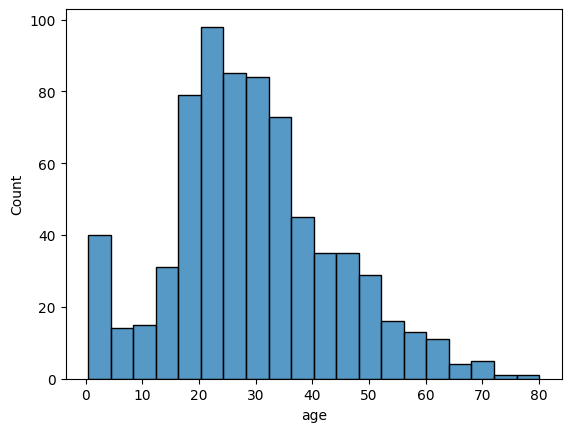

In [14]:
sns.histplot(df['age'])

In [ ]:
df['Age_mean'] = df['age'].fillna(df['age'].mean())

In [20]:
df[['Age_mean', 'age']]

,Age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


#### mean imputation works well when we have normally distributed data but if we have left or right skewed means there for sure are outliers in data so ..
### so we used median imputation 

In [28]:
df['age_median'] = df['age'].fillna(df['age'].median())

In [29]:
df[['age_median', 'Age_mean', 'age']]

,age_median,Age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


### mode imputation technique

Logic: Agar aapke kisi column mein missing data (NaN) hai, toh hum us column ki sabse common/frequent value (Mode) dhoondhte hain aur missing rows ki jagah wahi value fill kar dete hain.

2. Live Real-Life Examples
Categorical Feature (City):

Data: [Delhi, Mumbai, Delhi, Delhi, NaN, Bangalore, Delhi]

Yahan Mode = Delhi (kyunki sabse zyaada 4 baar aaya hai).

Imputation ke baad: NaN ki jagah Delhi bhar diya jayega.

In [31]:
df['embarked'].unique()

<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

In [35]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

print(mode_value)

S


In [36]:
df['embarked_mode'] = df['embarked'].fillna(mode_value)

In [37]:
df[['embarked_mode', 'embarked']]

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C


In [43]:
df['embarked_mode'].isnull().sum()

np.int64(0)